In [4]:
import pandas as pd
orders = pd.read_csv("orders.csv", sep=";")
orders["Order_Date"].head()

0    11.05.2026
1    16.02.2025
2    21.12.2025
3    22.04.2026
4    08.09.2025
Name: Order_Date, dtype: str

In [6]:
orders["Order_Date"]=pd.to_datetime(
    orders["Order_Date"],
    format="%d.%m.%Y",
    errors="coerce"
)
orders["Order_Date"].isna().sum()

np.int64(35)

In [10]:
order_items = pd.read_csv("order_items.csv", sep=";")
order_items_clean = order_items.drop_duplicates().copy()
order_items_clean.shape

(149673, 6)

In [12]:
order_items_clean["Quantity"]=pd.to_numeric(
    order_items_clean["Quantity"],
    errors="coerce")
order_items_clean["Unit_Price"]= pd.to_numeric(
    order_items_clean["Unit_Price"],
    errors="coerce")

In [13]:
order_items_clean["Revenue"] = (order_items_clean["Quantity"]*order_items_clean["Unit_Price"])
order_items_clean.shape

(149673, 7)

In [15]:
sales_time = order_items_clean.merge(
    orders[["Order_ID", "Order_Date"]],
        on="Order_ID",
how="left"
)
sales_time["Order_Date"].isna().sum()

np.int64(84)

In [16]:
sales_time=sales_time[sales_time["Order_Date"].notna()].copy()
sales_time["Month"]=sales_time["Order_Date"].dt.strftime("%Y-%m")

In [17]:
monthly_revenue = (sales_time.groupby("Month")["Revenue"].sum().sort_index())
monthly_revenue.head()

Month
2025-01    25641347.00
2025-02    23566203.61
2025-03    25496786.57
2025-04    24394949.35
2025-05    26752484.09
Name: Revenue, dtype: float64

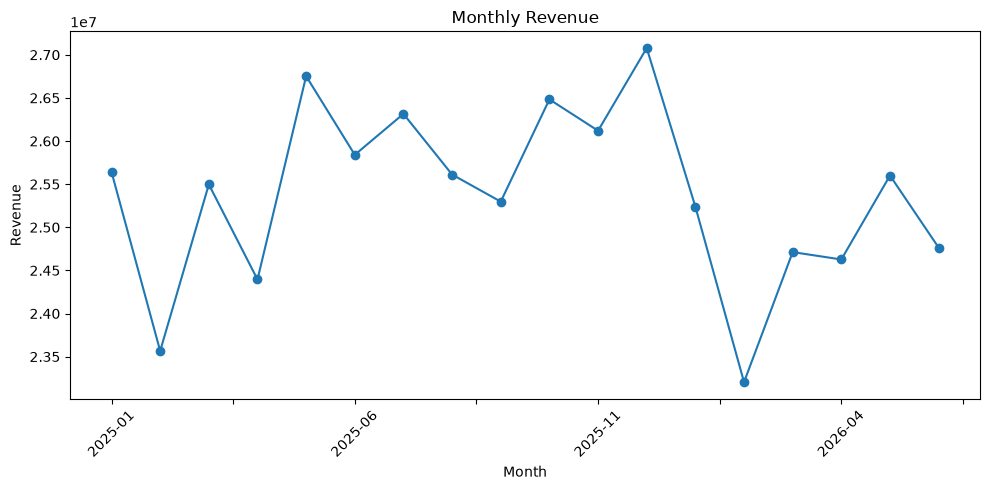

In [18]:
import matplotlib.pyplot as plt
monthly_revenue.plot(
    kind="line",
    figsize=(10,5),
    marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
monthly_revenue.idxmax(), monthly_revenue.max()

('2025-12', np.float64(27078321.11))

In [21]:
monthly_revenue.idxmin(), monthly_revenue.min()

('2026-02', np.float64(23204417.45))